# Star Wars Universe Analysis
This project explores the Star Wars universe using data pulled from the SWAPI API across three endpoints: people, species, and planets. The goal is to answer three questions: which species appears most across the films, how species compare physically in height and lifespan, and which planets are home to the most characters. Data was ingested, merged, cleaned, and analyzed entirely in Python before being exported for visualization in Tableau Public.

# 1. Setup & Imports

Importing the core libraries used throughout the project. `requests` handles API calls, `pandas` and `numpy` manage data manipulation and cleaning, and `matplotlib` supports exploratory visualizations.

In [227]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Data Ingestion

Data is pulled from three SWAPI endpoints: `/people`, `/species`, and `/planets`. Each endpoint paginates results across multiple pages. A `while` loop follows the `next` URL field in each response, collecting all records until `next` returns `None`. Results are accumulated into a flat list using `.extend()` and converted into a DataFrame.

In [228]:
all_species = []
url = "https://swapi.py4e.com/api/species/"

while url:
    response = requests.get(url)
    data = response.json()
    all_species.extend(data["results"])
    url = data["next"]

In [229]:
all_people = []
url = "https://swapi.py4e.com/api/people/"

while url:
    response = requests.get(url)
    data = response.json()
    all_people.extend(data["results"])
    url = data["next"]

In [230]:
all_planets = []
url = "https://swapi.py4e.com/api/planets/"

while url:
    response = requests.get(url)
    data = response.json()
    all_planets.extend(data["results"])
    url = data["next"]

In [231]:
all_species = pd.DataFrame(all_species)
all_people = pd.DataFrame(all_people)
all_planets = pd.DataFrame(all_planets)

## 3. Data Merging

The three DataFrames are connected using URL-based foreign keys, following the same logic as SQL joins. People are joined to species on the species URL field, and that result is joined to planets on the homeworld URL field. Post-merge, redundant URL columns and join keys are dropped, and duplicate name columns are renamed to `person_name`, `species_name`, and `planet_name` for clarity.

In [232]:
all_species = all_species[['name', 'classification', 'designation', 'average_height',
       'skin_colors', 'hair_colors', 'eye_colors', 'average_lifespan','url']]

all_people = all_people[['name', 'height', 'mass', 'hair_color', 'skin_color', 'eye_color',
       'birth_year', 'gender', 'homeworld', 'species', 'url']]


all_planets = all_planets[['name', 'rotation_period', 'orbital_period', 'diameter',
       'climate', 'gravity', 'terrain', 'surface_water', 'population', 'url']]

In [233]:
all_species['average_lifespan'] = all_species['average_lifespan'].replace(('unknown','indefinite'), np.nan)
all_species['average_lifespan'] = all_species['average_lifespan'].astype(float)
all_people['species'] = all_people['species'].apply(lambda x: x[0] if len(x) > 0 else np.nan)

In [234]:
result = pd.merge(all_people, all_species, left_on='species', right_on='url', how='inner')
df = pd.merge(result, all_planets, left_on='homeworld', right_on='url', how='inner')

In [235]:
df.drop(['url_x', 'url_y', 'url', 'homeworld', 'species'], axis=1, inplace=True)

In [236]:
df.rename(columns={'name_x': 'person_name', 'name_y': 'species_name', 'name': 'planet_name'}, inplace=True)

## 4. Data Cleaning

Several data quality issues were resolved before analysis:
- Numeric fields were stored as strings and converted to float
- Values of `unknown`, `none`, and `indefinite` were replaced with `NaN`
- Comma-formatted numbers were stripped prior to type conversion
- The species field in the people DataFrame was stored as a list — the first element was extracted with null handling for characters with no listed species

In [237]:
df['height'] = df['height'].replace(('unknown','none'), np.nan)
df['height'] = df['height'].astype(float)

df['diameter'] = df['diameter'].replace(('unknown'), np.nan)
df['diameter'] = df['diameter'].astype(float)

df['surface_water'] = df['surface_water'].replace(('unknown'), np.nan)
df['surface_water'] = df['surface_water'].astype(float)

df['rotation_period'] = df['rotation_period'].replace(('unknown'), np.nan)
df['rotation_period'] = df['rotation_period'].astype(float)

df['orbital_period'] = df['orbital_period'].replace(('unknown'), np.nan)
df['orbital_period'] = df['orbital_period'].astype(float)

df['population'] = df['population'].replace(('unknown'), np.nan)
df['population'] = df['population'].astype(float)

df['mass'] = df['mass'].str.replace(',', '')
df['mass'] = df['mass'].replace(('unknown'), np.nan)
df['mass'] = df['mass'].astype(float)


## 5. Exploratory Analysis

Three questions are answered through grouped aggregations and visualizations:
1. Which species appears most across the films?
2. How do species compare by average height and lifespan?
3. Which planets are home to the most characters?
Note: SWAPI covers the main saga films only. TV series are excluded, which understates representation for some species and characters.

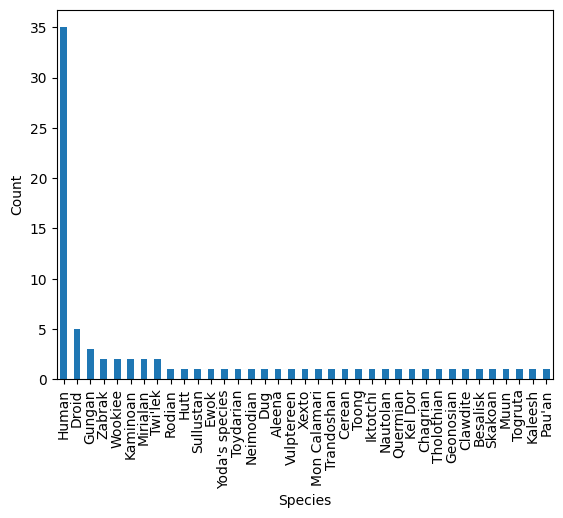

In [238]:
df['species_name'].value_counts().plot(kind='bar')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

In [239]:
df.groupby("species_name")["height"].mean().sort_values(ascending=False)

,height
species_name,
Quermian,264.000000
Wookiee,231.000000
Kaminoan,221.000000
Kaleesh,216.000000
Gungan,208.666667
Pau'an,206.000000
Besalisk,198.000000
Cerean,198.000000
Chagrian,196.000000


In [240]:
df.groupby("species_name")["average_lifespan"].mean().sort_values(ascending=False)

,average_lifespan
species_name,
Hutt,1000.0
Yoda's species,900.0
Pau'an,700.0
Wookiee,400.0
Human,120.0
Muun,100.0
Togruta,94.0
Toydarian,91.0
Quermian,86.0


In [241]:
df.groupby("planet_name")["species_name"].nunique().sort_values(ascending=False)

,species_name
planet_name,
Naboo,3
unknown,3
Coruscant,2
Kamino,2
Tatooine,2
Aleen Minor,1
Alderaan,1
Chandrila,1
Concord Dawn,1



## 6. Export

The cleaned, merged DataFrame is exported to CSV for use in Tableau Public. This file serves as the single source of truth for the dashboard.


In [242]:
from google.colab import files
df.to_csv('/content/drive/MyDrive/Data Analytic Projects for Portfolio/Star Wars Data Analysis/starwars_data', index=False)